Dataset Shape: (150, 4)


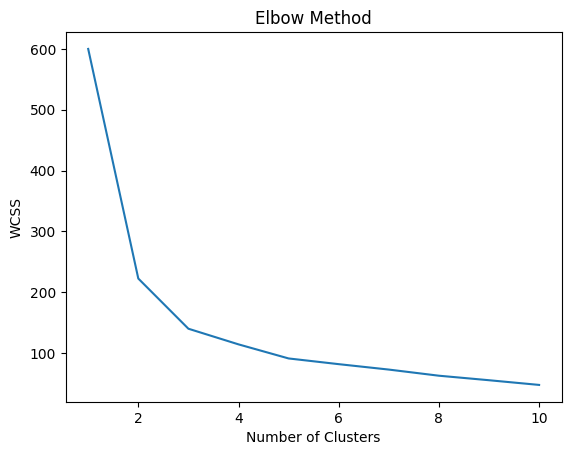

K-Means Silhouette Score: 0.45994823920518635


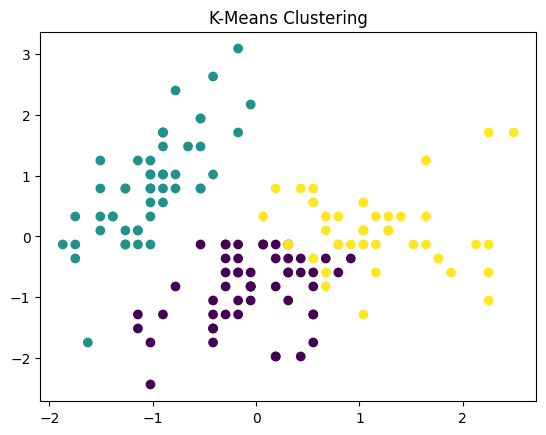

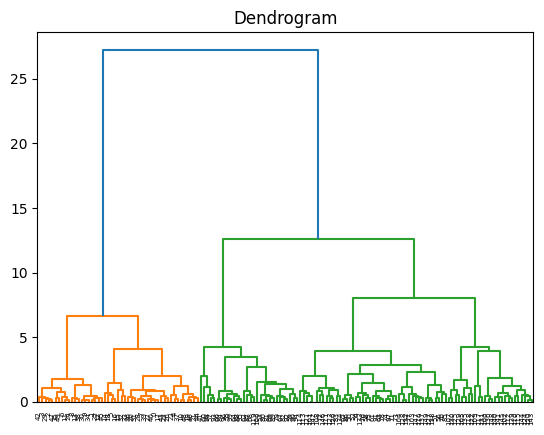

Hierarchical Silhouette Score: 0.4466890410285909


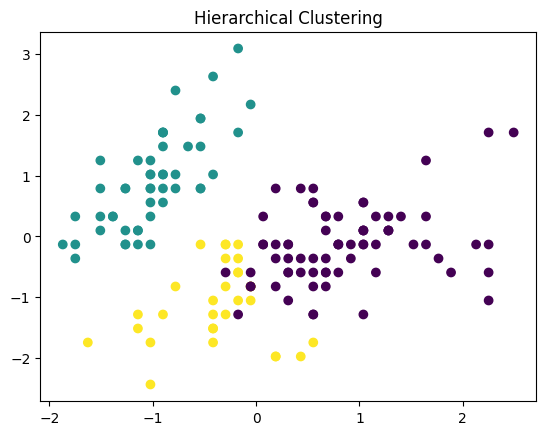

Experiment Completed Successfully ✅


In [1]:
# ============================
# EXPERIMENT 6
# K-Means & Hierarchical Clustering (Iris Dataset)
# ============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# ----------------------------
# 1. Load Dataset
# ----------------------------
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

print("Dataset Shape:", X.shape)

# ----------------------------
# 2. Feature Scaling
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# 3. K-Means Clustering
# ----------------------------

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Apply K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means Silhouette Score:",
      silhouette_score(X_scaled, kmeans_labels))

plt.figure()
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means Clustering")
plt.show()

# ----------------------------
# 4. Hierarchical Clustering
# ----------------------------

plt.figure()
linked = linkage(X_scaled, method='ward')
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

print("Hierarchical Silhouette Score:",
      silhouette_score(X_scaled, hc_labels))

plt.figure()
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.show()

print("Experiment Completed Successfully ✅")